## Параметрическое восстановление плотности коррелированных случайных величин

Задача восстановления плотности распределения случайных величин по доступной выборке имеет два общепринятых подхода к решению. Первый подход, который называется параметрическим, является предпочтительным, потому что функция плотности вероятности задается аналитически и имеет совершенно определенные статистические свойства. Восстановление плотности по выборке является оптимизационной задачей относительно вектора неизвестных параметров функции плотности. Эта задача решается методом максимального правдоподобия. Оценка метода находится при помощи различных алгоритомов оптимизации, например квазиньютоновским алгоритмом, градиентным спуском или ЕМ-алгоритмом. При этом сама форма функции никак не оптимизируется и выбирается исходя из знания предметной области, порождающей данную выборку. Часто оказывается, что функция является смесью нескольких компонент-распределений и в вектор параметров входит также относительная фракция каждой компоненты в общем распределении. 

Второй подход называется непараметрическим и используется в случаях, когда параметризовать функцию плотности не представляется возможным в виду ее сложности. Подход основан на ядерной оценке плотности (также применяется простая интерполяция данных). Ядерный метод сглаживает простую частотную оценку плотности вероятности непрерывной случайной величины. Частотной оценкой является гистограмма, т.е. кусочно-постоянная функция, которая, очевидно, не является непрерывной. Выбор ядерной функции является условным, хоть и коррелирует с качеством восстановления плотности. Параметр сглаживания (ширина бина гистограммы) является гиперпараметром подхода и может быть определен, например, с помощью кросс-валидации (Leave-one-out скользящий контроль). 

Теперь рассмотрим многомерную задачу, когда требуется восстановить функцию многих переменных. Вместо случайной величины рассматривается случайный вектор, компоненты которого могут коррелировать друг с другом. В случае некоррелированных компонент функция плотности распределения случайного вектора представима в виде произведения одномерных плотностей для каждой компоненты в отдельности. Таким образом многомерная задача свелась к одномерной. При наличии линейной корреляции между компонентами задача также сводится к одномерной диагонализацией матрицы ковариации и переходом в базис собственных векторов. При этом нужно иметь в виду, что новый базис может быть плохо интерпретируемым, когда теряется смысловое значение новых комопонент. Если есть нелиинейные корреляции, то задача не сводится к одномерной. 

Рассмотрим этот случай более детально. Положим, что мы не ограничены объемом выборки. Рассмотрим 2-мерный случайный вектор.
Чтобы включить корреляцию в плотность распределения, будем делить плоскость на области, ограниченные двумя прямыми, параллельными одной из осей координат. Ширины таких областей подбираются индивидуально. С одной стороны, они должны быть не слишком малыми, чтобы иметь достаточное число точек в них. Даже при очень больших, но конечных объемах выборки, ширина такой области будет ограничена снизу. С другой стороны, области должны быть не слишком большими, чтобы одномерные функции плотности, полученные интегрированием двумерной функции по данной области, были достаточно простыми, чтобы не чувствовать корреляцию. Таким образом в каждой области эта функция будет иметь одинаковый вид, но различные параметры. Зависимость этих параметров от второй переменной определяет искомую корреляцию. 
Простая аппроксимация этой зависимости функциями общего вида (например, полиномы) может приводить к неудовлетворительному описанию всей выборки. Причем это расхождение растет с увеличением числа зависимых параметров одномерной плотности. 

# Случай одномерной произвольной функции
Рассмотрим, как можно обойти эту проблему. Для этого сначала рассмотрим одномерную ненормированную непрерывную функцию общего вида $F(x)$, которую искусственно разделим на несколько кусочков. Поскольку функция изначально непрерывна, то все кусочки сшиваются между собой на границах областей разбиения. Пусть $F(x) = \sum_{i=1}^{9} a_i x^2 \Delta_i(x)$, где $\Delta_i(x) = H(x-b_i) - H(x-b_{i+1})$ бинирует распределение, $H(x)$ - пороговая функция, $b_i$ - границы областей разбиения (бинов); $a_i \sim iid \,\,\mathcal{U}(0,1)$ - некоторые числа, которые моделируются из равномерного распределения. 

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats, interpolate
import scipy.integrate as integrate

import warnings
warnings.filterwarnings('ignore')

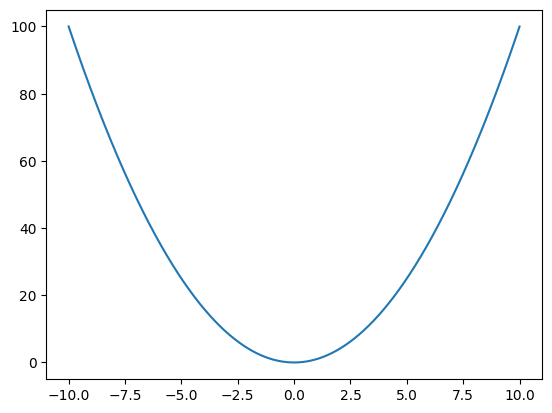

In [24]:
x = np.arange(-10,10,0.001) #  Полная область определения
y = x**2 # F(a,x), a=1
plt.plot(x,y);

In [25]:
# Разобьем область x на 9 равных бинов. 
b = np.linspace(-10,10,10) # граничные точки областей разбиения
delta=(b[-1]-b[0])/(len(b)-1) # ширина области разбиения

In [26]:
# step -  ступенька выделяющая каждый отдельный кусочек параболы, получается разностью функций Хевисайда. 
#np.heaviside (x0,x1), x1 - доопределение функции в точке разрыва.
step = [np.heaviside(x-b[i],1)-np.heaviside(x-b[i+1],1) for i in range(len(b)-1)]

In [27]:
res_step = np.zeros(len(y))
#coeff -  вес каждого кусочка параболы в общей функции
rng = np.random.default_rng(12345)
a = rng.uniform(size=len(step))
for j in range(len(step)):
    res_step += y*step[j]*a[j]
# res_step - функция F(a(x),x)

Таким образом мы имеем кусочно-непрерывную функцию с конечными скачками на границах областей разбиения $F(a(x),x)$. Здесь $a(x)$ - кусочно-постоянная функция, определяемая областями разбиения. Нарисуем $F(a(x),x)$.

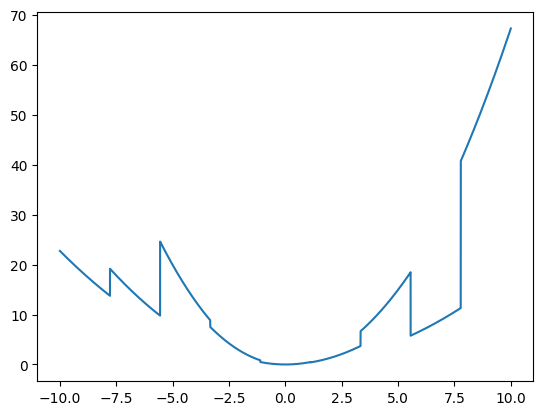

In [28]:
plt.plot(x,res_step);

А вот так выглядит зависимость $a(x)$.

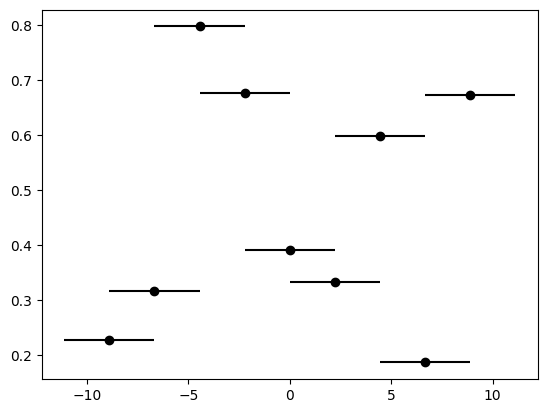

In [29]:
means = (b[1:]+b[:-1])/2 #Центры областей разбиения
plt.errorbar(means,a,xerr=delta,fmt='ok');

Видно, что есть сильные флуктуации значений. Поэтому аппроксимировать зависимость будет не просто. Одно из возможных решений - интерполяция точек полиномом (например. кубичным). 

In [30]:
# Функция интерполяции кубичными полиномами, с учетом граничных точек (-10; 10). 
def spline(x):
    tck = interpolate.splrep(np.r_[[-10],means,[10]], np.r_[[a[0]],a,[a[-1]]])
    return interpolate.splev(x, tck)

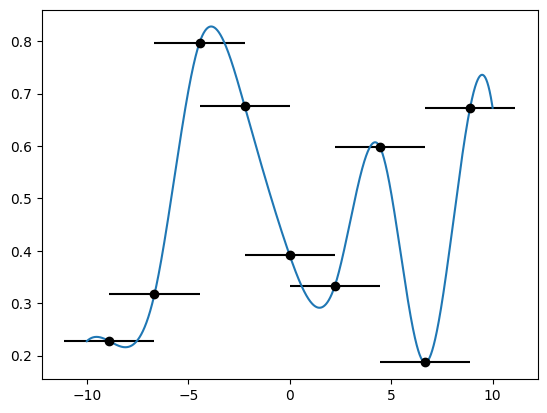

In [31]:
plt.errorbar(means,a,xerr=delta,fmt='ok')
plt.plot(x,spline(x));

Интерполяция зависимости $a_i$ восстанавливает непрерывность. При этом не нужно заморачиваться о виде функции аппроксимации. Посмотрим, как в итоге сглаживается функция $F(a(x),x)$.

In [32]:
res_spline = np.zeros(len(y))
for j in range(len(step)):
    res_spline += y*step[j]*spline(x)

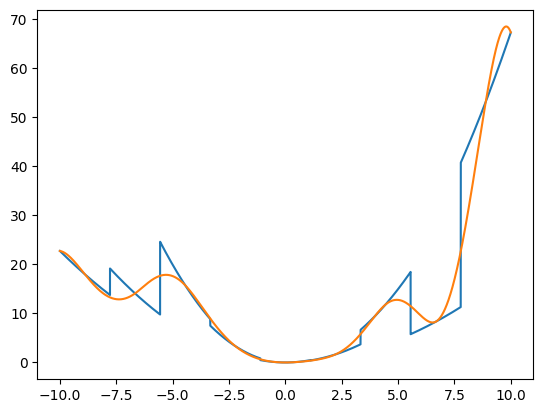

In [33]:
plt.plot(x,res_step);
plt.plot(x,res_spline);

Мы видим, что визуально гладкая аппроксимация кусочно-непрерывной функции вполне хорошая. 
Теперь попробуем сглаживать не зависимость $a_i$, а разность функций Хевисайда, как бы разглаживая области разбиения. 
Сделать это можно разными способами. Мы исследуем два способа. 

Первый - это замена разностей функций Хевисайда гауссианами со средним в центре бина и дисперсией в качестве оптиммизируемого гиперпараметра. 

In [34]:
#gauss = [stats.norm(loc=v,scale=3).rvs(200,random_state=42) for v in means]
#(np.sqrt(2 * np.pi) * sig)
def gaussian(x,mu,sig,N):
    return (
        N*np.exp(-np.power((x-mu)/sig,2.0)/2)
    )

In [35]:
res_gauss = np.zeros(len(y))
for j in range(len(step)):
    res_gauss += y*gaussian(x,means[j],0.8,1.)*a[j]

Оптимизация гиперпараметра будет простой. В качестве метрики качества модели будем использовать среднюю относительную ошибку МRE. Здесь мы  просто подбираем гипараметр, считая все точки тренировочным набором, поскольку сложно переобучиться в такой модели. Как бы мы не подбирали гиперпараметры, мы не добьемся точного описания данных.  

In [36]:
# Оптимизация rms гауссиана c использованием метрики MRE
mre_max = 1e6
sigma_opt = None
N_opt = None
for sigma,N in np.stack(np.meshgrid(np.arange(0.1,5,0.1),np.arange(0.1,5,0.1)),axis=-1).reshape(-1,2):
    res_gauss_t = np.zeros(len(y))
    for j in range(len(step)):
        res_gauss_t += y*gaussian(x,means[j],sigma,N)*a[j]
    mre = np.mean(np.divide(np.abs(res_step-res_gauss_t), res_step))
    if mre < mre_max:
        mre_max = mre
        sigma_opt = sigma
        N_opt = N
mre_max, sigma_opt, N_opt

(np.float64(0.15426299008600655), np.float64(0.8), np.float64(1.0))

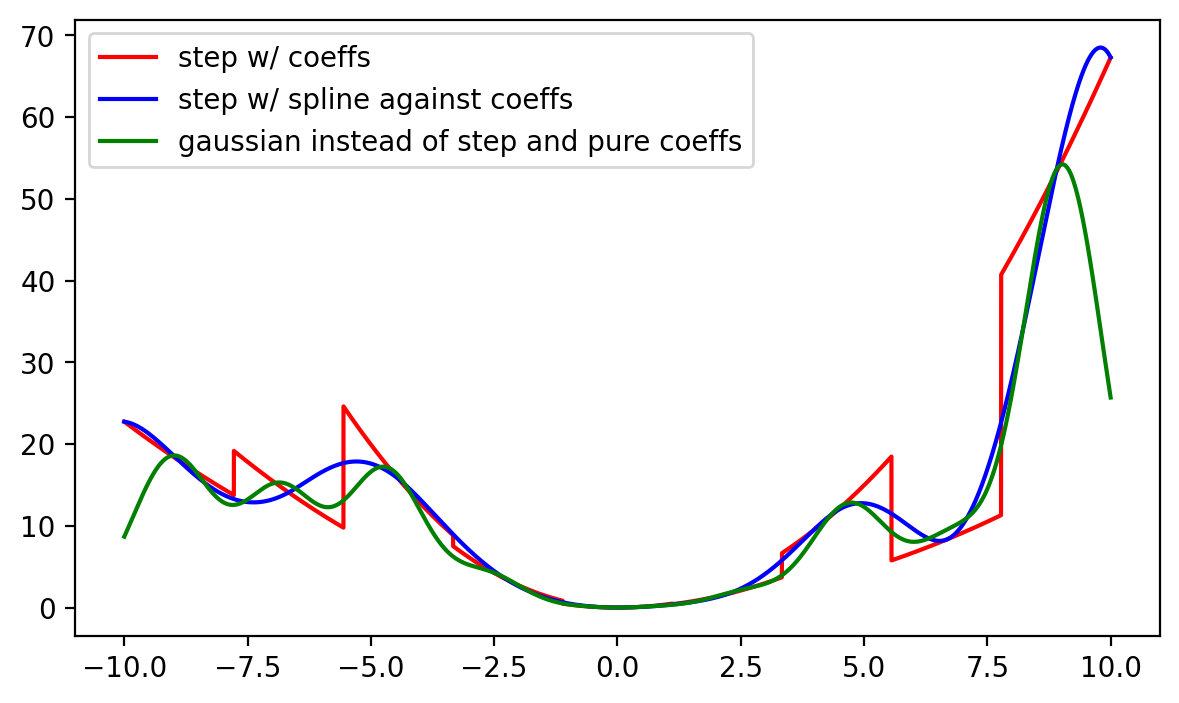

In [39]:
plt.figure(figsize=(7,4),dpi=200)
plt.plot(x,res_step,color='r',label='step w/ coeffs');
plt.plot(x,res_spline,color='b',label='step w/ spline against coeffs');
plt.plot(x,res_gauss,color='g',label='gaussian instead of step and pure coeffs');
plt.legend(loc='upper left');

Видно, что гауссова аппроксимация областей в целом тоже неплохо сглаживает функцию, хотя и видны сильные расхождения в окрестности концевых точек. Мы специально это учитывали в процедуре интерполяции, а здесь все-таки гауссианы накапливаются на границах.

Теперь посмотрим второй способ, основанный на гладкой аппроксимации пороговой функции. В нейронных сетях используется сигмоидальная функция $\sigma(k,x)$, которая хорошо сглаживает углы. 
$$ 
\sigma(x) = \frac{1}{1+e^{-kx}}
$$

С ее помощью можно сколь угодно точно гладко аппроксимровать кусочно-непрерывную функцию. Параметр $k$ можно интерпретировать как быстроту изменения сигмоида (чем больше $k$, тем быстрее функция меняет свои значения в окрестности нуля). Увеличивая параметр $k$ мы будем все точнее приближать сигмоид к ступеньке. Различие будет видно только в небольшой окрестности точки разрыва функции Хевисайда. В самой точке различие невозможно будет устранить увеличивая $k$. Однако мы можем формально сдвинуть крайние точки разрыва за область определения функции. Тогда можно добиться сколь угодно точного приближения к функции. 
Если $F(x)$ кусочно-непрерывна, как в рассматриваемом выше примере, то задача решается просто заданием достаточно большого значения $k$.  

Заметим, что мы не можем просто наложить штраф на большие градиенты сигмоида в точке разрыва. На границах бинов производная $\sigma'(0) = k/4$, так что регуляризация будет состоять в добавлении члена, пропорционального $k^2$ (чтобы исключить отрицательные $k$). При этом появится дополнительный гиперпараметр регуляризации, который будет учитывать силу штрафа. Сама модель имеет всего лишь один параметр, $k$. Таким образом задача состоит в минимизации функции одного аргумента при условии в виде неравенства $k^2 \le c$, где $c$ - предельное значение квадрата градиента на границе бинов. Согласно теореме Куна-Таккера, такая задача решается минимизацией функционала: 
$$
\mathcal{Q}(k) = \sum_{i=1}^{9} a_i x^2 \mathcal{L}(\sigma(k(x-b_i))-\sigma(k(x-b_{i+1}),H(x-b_i) - H(x-b_{i+1})) + \lambda k^2{,}
$$
где $\lambda$ - фиксированный гиперпараметр функционала $\mathcal{Q}$, который однозначно связан с максимальным значением квадрата градиента $c$ и $\mathcal{L}$ - некоторая функция потерь. Фиксируя $\lambda$, мы, в конечном счете, фиксируем $k$, поскольку работает условие дополняющей нежесткости $\lambda (k^2 - c) = 0$, где $\lambda \neq 0$.

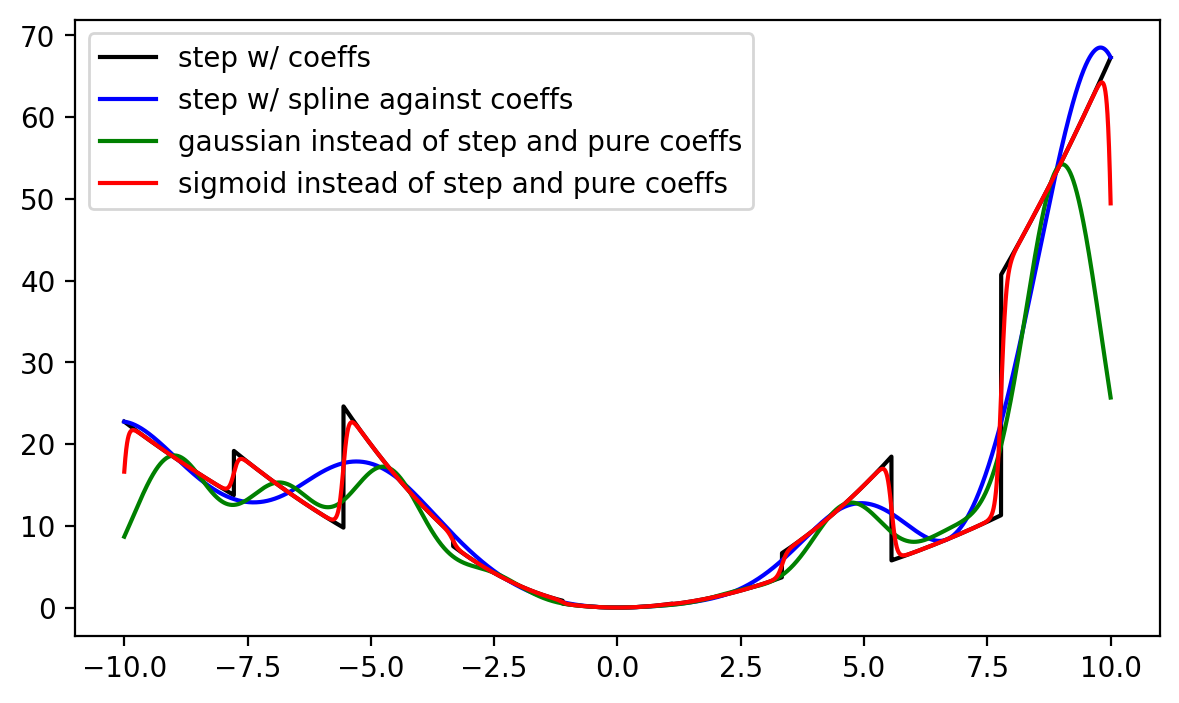

In [42]:
k = 20 # произвольно заданный параметр сигмоида
# эмпирическая сдвижка границ первого и последнего бинов, чтобы улучшить апроксимацию функцией на границах
delta = [-1/k] + list(np.zeros(len(b)-2)) + [1/k]
def sigmoid(x,k):
    return 1./(1+np.exp(-k*x))

res_smoothed_step = np.zeros(len(y))
smoothed_step = [sigmoid(x-b[i]-delta[i],k)-sigmoid(x-b[i+1]-delta[i+1],k) for i in range(len(b)-1)]
for j in range(len(smoothed_step)):
    res_smoothed_step += y*smoothed_step[j]*a[j]

plt.figure(figsize=(7,4),dpi=200)
plt.plot(x,res_step,color='black',label='step w/ coeffs');
plt.plot(x,res_spline,color='b',label='step w/ spline against coeffs');
plt.plot(x,res_gauss,color='g',label='gaussian instead of step and pure coeffs');
plt.plot(x,res_smoothed_step,color='r',label='sigmoid instead of step and pure coeffs');
plt.legend(loc='upper left');

# Случай многомерной функции плотности вероятности

Теперь рассмотрим случай с данными случайной природы, которые описываются непрерывной функцией распределения, которая уже является нормированной. 
Рассмотрим для простоты двумерный случай. Пусть $g(x,y)=F(x|y)G(y)$ - совместная плотность распределения. Такая запись означает, что в двумерной плотности учитываются корреляции между $x$ и $y$. 
Условия нормировки выглядят следующим образом:
\begin{eqnarray}
\int F(x|y) dx &=& 1, \, \, \, \forall y \\
\int G(y) dy &=& 1
\end{eqnarray}
В результате плотность $g(x,y)$ автоматически нормирована. 

В общем случае мы должны разбивать данные на области по $y$. Затем подгонять данные в каждой области некоторой плотностью распределения $F(x|y$) и размазывать (или сшивать) плотности для разных областей по $y$. В условной плотности $F(x|y$) параметры распределения зависят от $y$. Если эти зависимости удается аппроксимировать гладкими функциями, то задача решена и плотность $g(x,y)$ построена. Если же параметров много и зависимости получаются сложными, можно пойти другим путем и условную плотность $F(x|y)$ приближенно представить в виде суммы плотностей в каждой области разбиения.
$$
F(x|y;k) \approx \sum_{i=1}^n \mathcal{J}(x;\vec{a_i})\Sigma_i(y){,}
$$
где $\mathcal{J}(x;\vec{a_i})$ - $x$-плотность, зависящая от вектора параметров $\vec{a_i}$ в данной области $i$ 
по координате $y$; 
$$\Sigma_i(y;k) = \Sigma(y;k,b_i,b_{i+1})=\sigma(k(y-b_i))-\sigma(k(y-b_{i+1}))
$$ 
является разностью сигмоид, выделяющей область с границами $b_i$ и $b_{i+1}$.
Такое представление является приближенным, поскольку условие нормировки $\int F(x|y) dx = 1$ 
не является точным:
$$
\int F(x|y)dx \approx \int \sum_{i=1}^n \mathcal{J}(x,\vec{a_i}) \Sigma_i(y) dx = \sum_{i=1}^n \Sigma_i(y) = 
\Sigma(y;k,b_{min},b_{max})
$$
Параметры $b_{min}$ и $b_{max}$ определяют границы области фитирования. Чем больше $k$, тем сильнее склон сигмоида приближается к ступеньке
и функция $\Sigma(y;k,b_{min},b_{max})$ напоминает пороговую функцию:
$$
\Sigma(y;k,b_{min},b_{max}) \overset{k \to \infty}{\to}
\begin{cases}
1, &  y \in [b_{min},b_{max}] \\
0, & \text{otherwise}
\end{cases}
$$

В результате для представления плотности $g(x,y) \approx \sum_{i=1}^n \mathcal{J}(x;\vec{a_i})\Sigma_i(y)G(y)/I$  потребуется нормировочный интеграл $I$:
$$
I = \sum_{i=1}^n \int G(y) \Sigma_i(y;k) dy = \int G(y) \sum_{i=1}^n \Sigma_i(y;k) dy = \int G(y) \Sigma(y;k,b_{min},b_{max}) dy
$$

Заметим, что представление $F(x|y)$ через функции $\Sigma_i(y)$ совпадает с гладкой ступенчатой аппроксимацией параметров $\vec{a}(y)$ в функции $\mathcal{J}(x,\vec{a}(y))$ (с той точностью, с которой нормировку $F(x|y)dy \simeq 1$  можно считать единичной):
$$
\begin{aligned}
F(x|y) & = \mathcal{J}(x,\sum_{i=1}^n\vec{a_i}\Sigma_i(y)) = \sum_{l=0}^{\infty} \mathcal{J}^{(l)}(x,0) \frac{(\sum_{i=1}^n\vec{a_i}\Sigma_i(y))^l}{l!}  \approx \sum_{l=0}^{\infty} \mathcal{J}^{(l)}(x,0) \frac{\sum_{i=1}^n\vec{a}_i^l\Sigma_i(y)}{l!} \\ 
& = \sum_{i=1}^n\Sigma_i(y)\sum_{l=0}^{\infty}\mathcal{J}^{(l)}(x,0)\frac{\vec{a}_i^l}{l!} = 
\sum_{i=1}^n\mathcal{J}(x,\vec{a}_i)\Sigma_i(y)
\end{aligned}
$$


Напишем выражения для $x$, $y$-проекций плотности $g(k;x,y)$.
$x$-проекция имеет вид:
$$
\int g(x,y;k) dy = \int \sum_{i=1}^n \frac{\mathcal{J}(x,\vec{a_i})\Sigma_i(y;k)}{I}G(y)dy = 
\sum_{i=1}^n c_i(k) \mathcal{J}(x,\vec{a_i}){,}
$$
где
$$
c_i(k) = \frac{\int \Sigma_i(y;k)G(y)dy}{I}, \, \, \, \, \, \sum_{i=1}^n c_i(k)= 1, \, \,\ \, \forall k
$$
является долей $i$-ой области по $y$ в $x$-проекцию. 

$y$-проекция имеет вид:
$$
\int g(x,y;k) dx = \sum_{i=1}^n \frac{\Sigma_i(y;k)G(y)}{I} \int \mathcal{J}(x,\vec{a_i}) dx = 
\sum_{i=1}^n \frac{\Sigma_i(y;k)G(y)}{I}
$$

Понятно, что с ростом $k$  описание данных будет подстраиваться под конкретное разбиение данных на области. Следовательно нужно как-то по-другому разбивать данные. 
Возможная эвристика состоит в сдвиге границ областей таким образом, чтобы границы новых областей приходились на середины первоначальных.

Будем генерить случайные векторы с плотностью $F(x,y) = G(x)U(y)$, где $G(x)$ - стандартная нормальная плотность и $U(y)$ - равномерная плотность на единичном отрезке. Переменные $x$ и $y$ будут независимыми случайными величинами. Но мы все равно выделим области в данных. Разобьем отрезок переменной $y$ на области (бины) и фитируем данные по $x$ в каждом бине $y$. Затем сформируем модель с параметром $k$:
$$
G(x) \approx G(k;x|y) = \sum_{i=1}^{n} a_i G(x;\mu_i,\sigma_i) (\sigma(k(y-b_i))-\sigma(k(y-b_{i+1})){,}
$$
где $\mu_i$, $\sigma_i$ - параметры из обучающей выборки. 
Коэффициенты $a_i$ являются нормировками для функции $G(k;x|y)U(y)=G(k;x|y)$:
$$
a_i = \left(\log\frac{(1+e^{k(1-b_i)})(1+e^{-kb_{i+1}})}{(1+e^{-kb_i})(1+e^{k(1-b_{i+1})})}\right) / \left( 2 \log \, \cosh (\frac{k}{2}) \right)
$$
Они обеспечивают условие для плотности вероятности:
$$
\int_{-\infty}^{\infty}\int_{-\infty}^{\infty}G(k;x|y)U(y)dxdy = 1
$$
Поскольку
\begin{eqnarray}
\int_{-\infty}^{\infty}U(y)dy = \int_0^1 dy &=& 1 \\
\int_{\infty}^{\infty}G(x;\mu_i,\sigma_i)dx &=& 1
\end{eqnarray}
Далее, сделаем разбиение со сдвигом границ новых бинов в середины старых. 
$$
\tilde{G}(x|y) = \sum_{j=1}^{m=n-1} b_j G(x;\mu_j,\sigma_j) (H(y-m_j)-H(y-m_{j+1}){,}
$$
где $m_j=(b_j+b_{j+1})/2$. 
Здесь вместо сигмоид мы будем использовать ступеньки (ф. Хевисайда) и дополнительные нормировочные коэффициенты
$$
b_j = m_{j+1} - m_{j}
$$
Тогда метрикой качества модели будет разность, напоминающая метрику MAE,
$$
\Delta = \frac{\sum_{i=1}^{N_{data}} |G(k,(x|y)_i)-\tilde{G}((x|y)_i)|}{N_{data}}{.}
$$


In [16]:
bins = 9
xx = stats.norm.rvs(size=int(1e4),random_state=101)
yy = stats.uniform.rvs(loc=0,scale=1,size=int(1e4),random_state=101)
data = np.c_[xx,yy]
n,xe = np.histogram(yy,bins=bins)
means = (xe[1:] + xe[:-1])/2
delta = (xe[1:] - xe[:-1])/2
means, xe,delta

(array([0.05581991, 0.16689747, 0.27797503, 0.38905258, 0.50013014,
        0.6112077 , 0.72228526, 0.83336281, 0.94444037]),
 array([2.81131949e-04, 1.11358690e-01, 2.22436247e-01, 3.33513805e-01,
        4.44591363e-01, 5.55668920e-01, 6.66746478e-01, 7.77824036e-01,
        8.88901593e-01, 9.99979151e-01]),
 array([0.05553878, 0.05553878, 0.05553878, 0.05553878, 0.05553878,
        0.05553878, 0.05553878, 0.05553878, 0.05553878]))

In [17]:
#from sklearn.model_selection import train_test_split
from iminuit import cost, Minuit
#data_train,data_test,_,_ = train_test_split(data,yy,test_size=0.3,random_state=101)
def pdf(x,mu,sigma):
    return stats.norm.pdf(x,loc=mu,scale=sigma)
mu_1,mu_2 = [],[]
mu_1_err,mu_2_err = [], []
sig_1,sig_2 = [],[]
sig_1_err,sig_2_err = [],[]
for i in np.arange(bins):
    condition = (data[:,1] > xe[i]) & (data[:,1] < xe[i+1])
    #print(data_train[condition][:,0])
    c = cost.UnbinnedNLL(data[condition][:,0],pdf)
    m = Minuit(c,mu=0,sigma=1)
    m.migrad()
    m.limits["sigma"] = (0, None)
    mu_1.append(m.values["mu"])
    sig_1.append(m.values["sigma"])
    mu_1_err.append(m.errors["mu"])
    sig_1_err.append(m.errors["sigma"])
for i in np.arange(bins-1):
    condition = (data[:,1] > means[i]) & (data[:,1] < means[i+1])
    #print(data_train[condition][:,0])
    c = cost.UnbinnedNLL(data[condition][:,0],pdf)
    m = Minuit(c,mu=0,sigma=1)
    m.migrad()
    m.limits["sigma"] = (0, None)
    mu_2.append(m.values["mu"])
    sig_2.append(m.values["sigma"])
    mu_2_err.append(m.errors["mu"])
    sig_2_err.append(m.errors["sigma"])

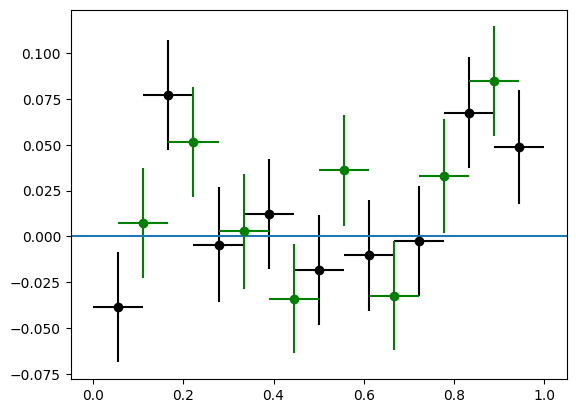

In [18]:
plt.errorbar(means,mu_1,xerr=delta,yerr=mu_1_err,fmt='ok')
eb = plt.errorbar(xe[1:-1],mu_2,xerr=delta[1:],yerr=mu_2_err,fmt='og')
plt.axhline()

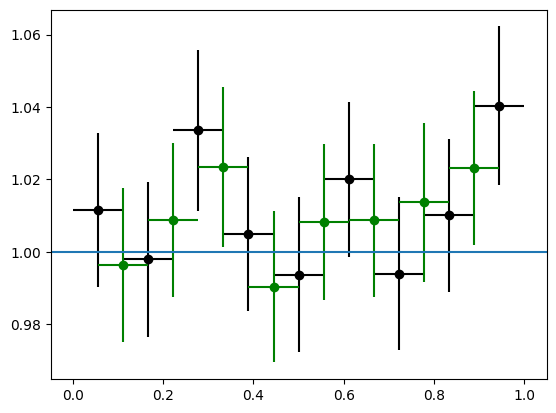

In [19]:
plt.errorbar(means,sig_1,xerr=delta,yerr=sig_1_err,fmt='ok')
plt.errorbar(xe[1:-1],sig_2,xerr=delta[1:],yerr=sig_2_err,fmt='og')
plt.axhline(1)

In [20]:
# Оптимизация модели сигмоида 
loss_max = 1e6
loss_ = []
k_opt = None
def get_f(x,y,xe,k,mu,sig,opt):
    #x = data[:,0]
    #y = data[:,1]
    res_smoothed_step = np.zeros(len(x))
    for i in range(len(xe)-1):
        if opt == 1:
            a  = k / 2 / np.log(np.cosh(k/2))
            smoothed_step = sigmoid(y-xe[i],k)-sigmoid(y-xe[i+1],k)
        elif opt == 2:
            a = 1
            smoothed_step = np.heaviside(y-xe[i],1)-np.heaviside(y-xe[i+1],1)
        res_smoothed_step += pdf(x,mu[i],sig[i])*smoothed_step*a
    return res_smoothed_step

condition = (data[:,1] > means[0]) & (data[:,1] < means[bins-1])
data_inner = data[condition]
x = data_inner[:,0]
y = data_inner[:,1]
for k in np.arange(1,400,20):
    loss = np.mean(np.abs(get_f(x,y,xe,k,mu_1,sig_1,1) - get_f(x,y,means,k,mu_2,sig_2,2)))
    loss_.append(loss)
    if loss < loss_max:
        loss_max  = loss
        k_opt = k
loss_max,k_opt

(np.float64(0.0060660536431207945), np.int64(221))

Мы видим, что значение $k$ стабилизируется. Стоит отметить, что $k$ включает в себя масштаб переменной $y$ при фиксированном количестве бинов разбиения. Растягивая или сжимая $y$, мы сжимаем или растягиваем $k$ так, что $k\,y$ не меняется.  В данном случае лучше использовать метод локтя для поиска точки излома, когда метрика качества перестает сильно уменьшаться и выходит на "полочку".  
Нарисуем метрику качества в зависимости от параметра k. Мы видим, что при $k=1$ она примерно имеет такие же значения, что и при $k>100$, а при $k=25$ достигает максимума. 

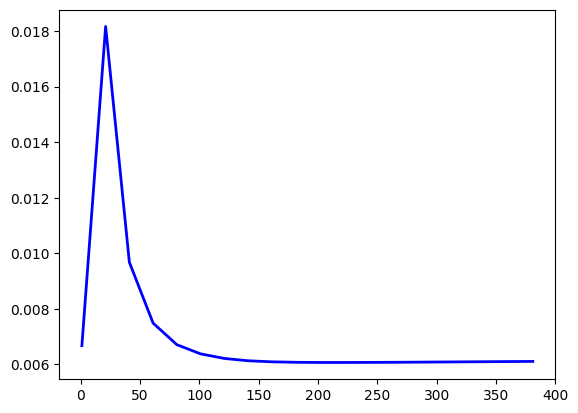

In [21]:
plt.plot(np.arange(1,400,20),loss_,color='blue',linewidth=2)

Нарисуем проекцию распределения $F(x,y$) на ось $x$. 
Поскольку в нашем примере $U(y)=1$,при $0 \le y \le 1$ и $0$ иначе, то в случае интегрирования с пороговой функцией мы получим усредненный на отрезке $ y \in [0,1]$ гауссиан. Если в каждой области разбиения гауссиан один и тот же, то результатом интегрирования является просто этот гауссиан. 

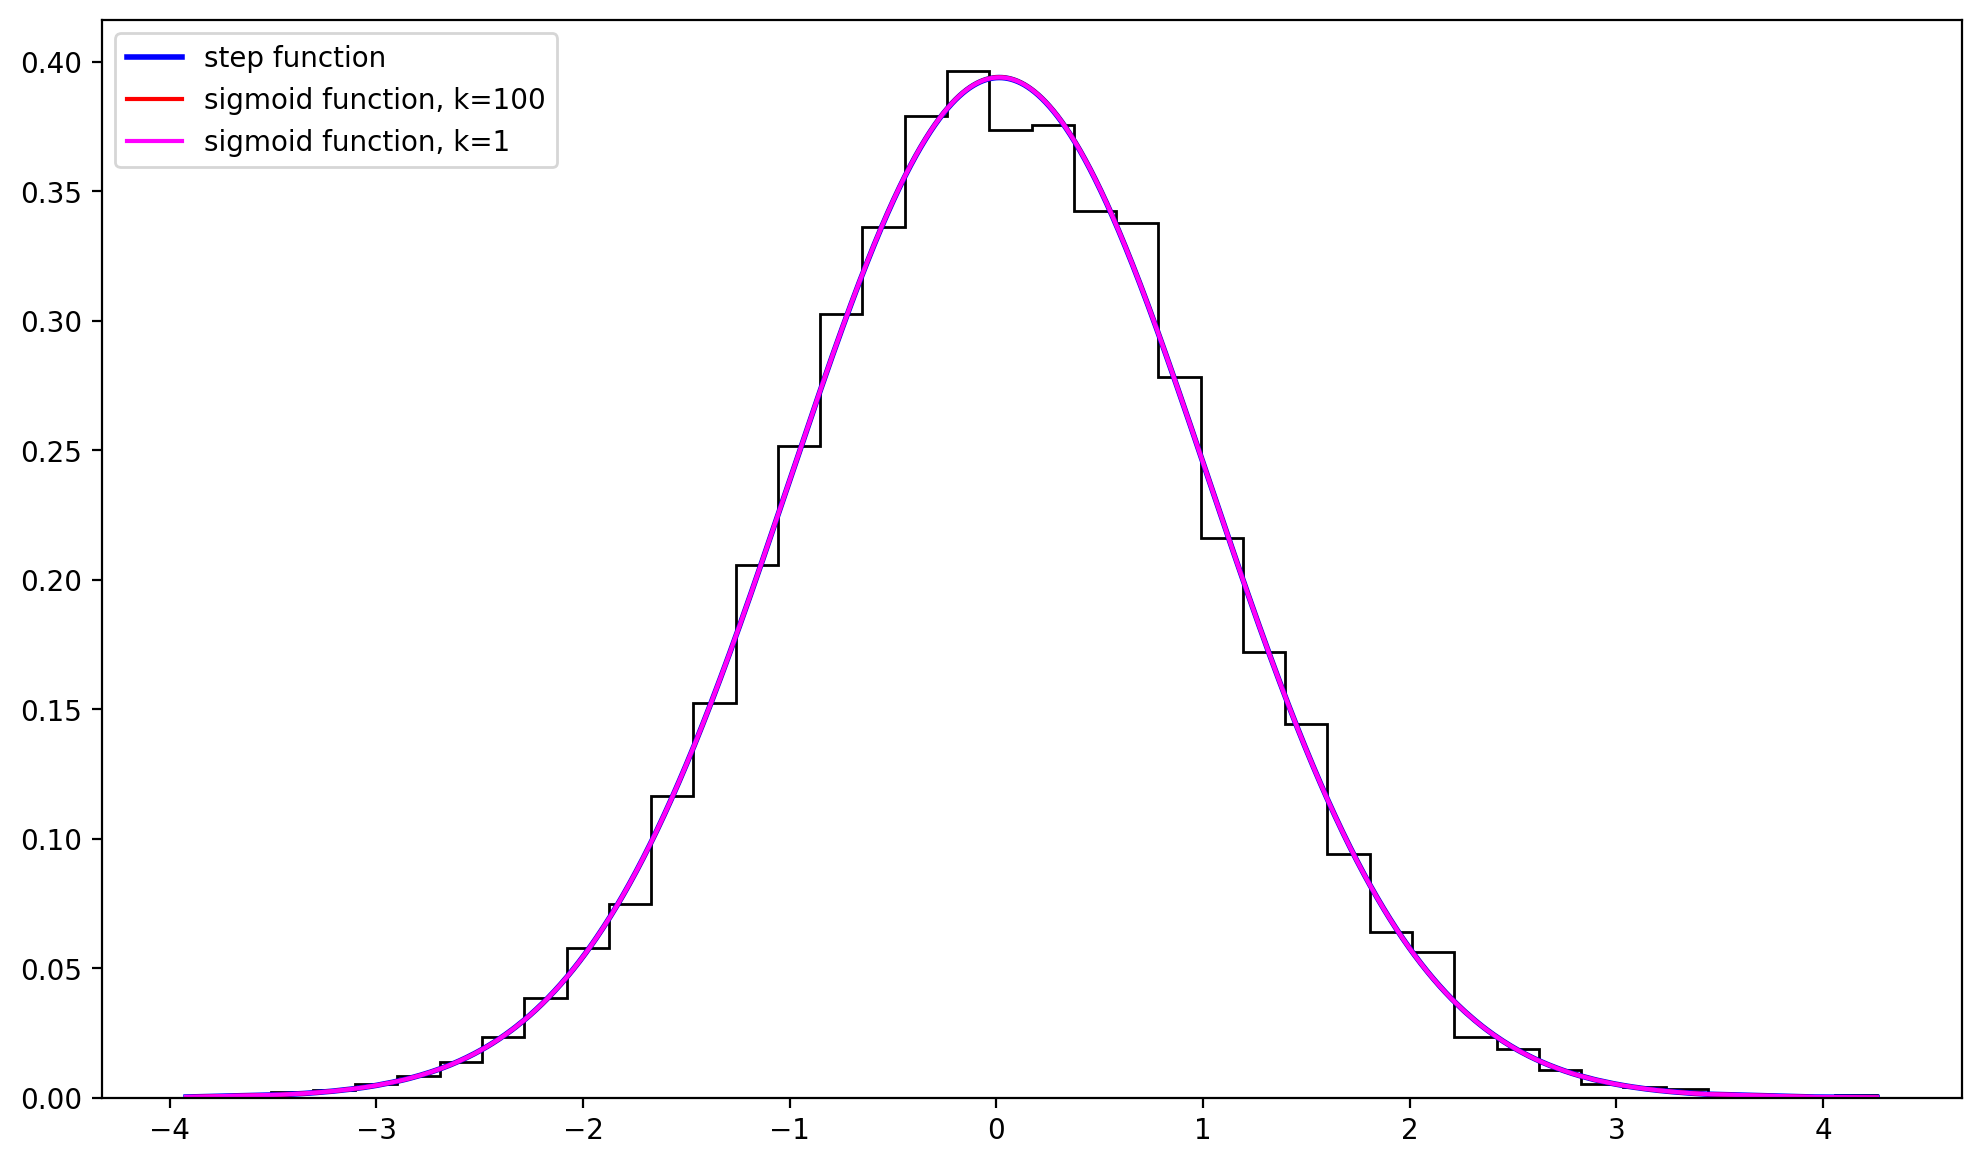

In [22]:
def get_f(x,xe,k,opt):
    f = 0
    for i in range(len(xe)-1):
        if opt == 1:
            numerator = (1+np.exp(k-k*xe[i]))*(1+np.exp(-k*xe[i+1]))
            denominator = (1+np.exp(-k*xe[i]))*(1+np.exp(k-k*xe[i+1]))
            a = np.log(numerator/denominator) 
            a  = a/(2*np.log(np.cosh(k/2))) 
        else:
            a = xe[i+1]-xe[i]
        f += pdf(x,mu_1[i],sig_1[i])*a
    return f
        
plt.figure(figsize=(12,7),dpi=200)
plt.hist(data[:,0],bins=40,density=True,histtype='step',color='black')
data_sorted = np.sort(data[:,0])
plt.plot(data_sorted,get_f(data_sorted,xe,0,2),color='blue',linewidth=2,label='step function')
plt.plot(data_sorted,get_f(data_sorted,xe,100,1),color='red',label='sigmoid function, k=100')
plt.plot(data_sorted,get_f(data_sorted,xe,1,1),color='magenta',label='sigmoid function, k=1')
plt.legend(loc='upper left')

На проекции все плотности слились в одную кривую, поэтому нарисуем разницу для трех значений $k=1,25,100$.

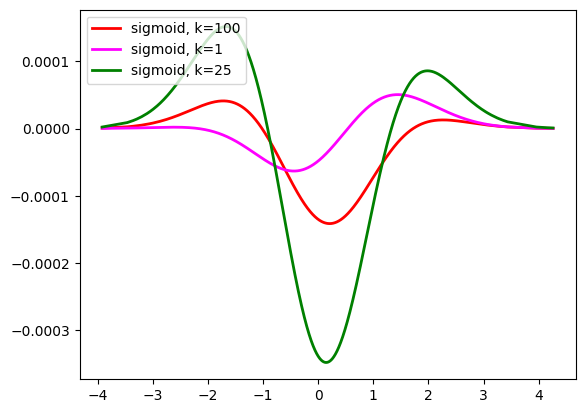

In [23]:
plt.plot(data_sorted,get_f(data_sorted,xe,0,2)-get_f(data_sorted,xe,100,1),color='red',linewidth=2,label='sigmoid, k=100')
plt.plot(data_sorted,get_f(data_sorted,xe,0,2)-get_f(data_sorted,xe,1,1),color='magenta',linewidth=2,label='sigmoid, k=1')
plt.plot(data_sorted,get_f(data_sorted,xe,0,2)-get_f(data_sorted,xe,25,1),color='green',linewidth=2,label='sigmoid, k=25')

plt.legend(loc='upper left')


Мы видим, что значение $k=1$ является вполне оптимальным. 

Теперь будем генерить случайные векторы с плотностью $F(x,y) = G(x,y)U(y)$, где $G(x,y)$ - гауссова плотность с зависимостями $\mu(y) = y$ и $\sigma(y) = 0.5 + y^2$ и $U(y)$ - равномерная плотность на отрезке $y \in [-1;1]$. Переменные $x$ и $y$ будут зависимыми случайными величинами c нетривиальной квадратичной корреляцией по параметру $\sigma$. Для генерации воспользуемся авторским модулем `roofit_functional`

In [2]:
import roofit_functional as rff

In [3]:
mu = rff.RooFitVar({'y' : [-1,1]}, 'p1*y', {'p1' : 1},'mu_function')
sigma = rff.RooFitVar({'all' : mu}, 'p0+p1*y**2', {'p0' : [0.5,0.5,0.5], 'p1' : 1},'sigma_function')
gauss_xy_0 = rff.RooFitFunction('Gauss_xy', {'x' : [-6,6], }, 'Gaussian', {'mu' : [0,-1,1], 'sigma' : [1,0.5,1.5]})
gauss_xy = gauss_xy_0.get_composition({'mu' : mu, 'sigma' : sigma})

In [4]:
uniform_y = rff.RooFitFunction('Uniform_y', {'all' : mu}, 'Uniform', {})

In [5]:
f_xy = gauss_xy * uniform_y
dataset = rff.RooFitData("sim","unbinned",(f_xy,50000),f_xy.x,seed=1234)

In [6]:
p1 = rff.RooFitPlot(dataset,f_xy,"x","x projection plot")

Gaussian|(y)
[#1] INFO:Plotting -- RooAbsReal::plotOn(Gauss_xy * Uniform_y) plot on x integrates over variables (y)
[#1] INFO:NumericIntegration -- RooRealIntegral::init([Uniform_y_NORM[y]_X_Gauss_xy_NORM[x]]_Int[y]) using numeric integrator RooIntegrator1D to calculate Int(y)


Gaussian|(y)


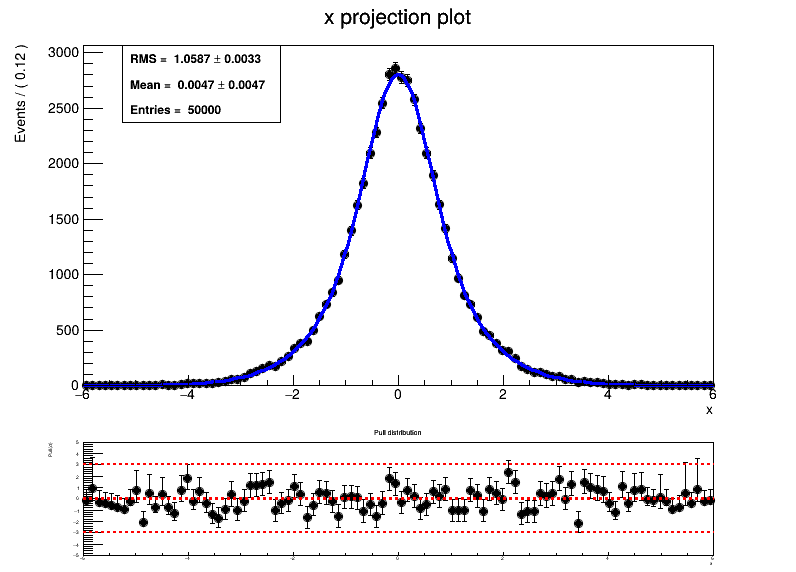

[#1] INFO:Plotting -- RooAbsReal::plotOn(Gauss_xy * Uniform_y) plot on x integrates over variables (y)
[#1] INFO:NumericIntegration -- RooRealIntegral::init([Uniform_y_NORM[y]_X_Gauss_xy_NORM[x]]_Int[y]) using numeric integrator RooIntegrator1D to calculate Int(y)


Info in <TCanvas::Print>: png file pull.png has been created


In [7]:
%jsroot on
p1 = rff.RooFitPlot(dataset,f_xy,"x","x projection plot")
p1.set_statOn()
p1.make_pullplot(pdf_format=False)
from IPython.display import Image
Image(filename='pull.png') 

In [8]:
p = rff.RooFitPlot(dataset,f_xy,"x","x projection plot",Slice={'y' : (0.8,1)})

Gaussian|(y)
[#1] INFO:Eval -- RooRealVar::setRange(y) new range named 'slice' created with bounds [0.8,1]
[#1] INFO:Plotting -- RooTreeData::plotOn: plotting 5058 events out of 50000 total events
[#1] INFO:Plotting -- RooAbsReal::plotOn(Gauss_xy * Uniform_y) plot on x integrates over variables (y) in range slice
[#1] INFO:NumericIntegration -- RooRealIntegral::init([Uniform_y_NORM[y]_X_Gauss_xy_NORM[x]]_Int[y|slice]) using numeric integrator RooIntegrator1D to calculate Int(y)


С помощью пакета `roofit_functional` можно рисовать плотность вероятности и данные выборки в разных слайсах области определения. Так объект 'p' определен для слайса $y \in [0.5;0.7]$. В этом слайсе можно легко нарисовать проекцию по оси $x$. При этом двумерная форма плотности вероятности отрисовывается на всех доступных данных вне зависимости от значения параметра `Slice` в классе `RooFitPlot`.

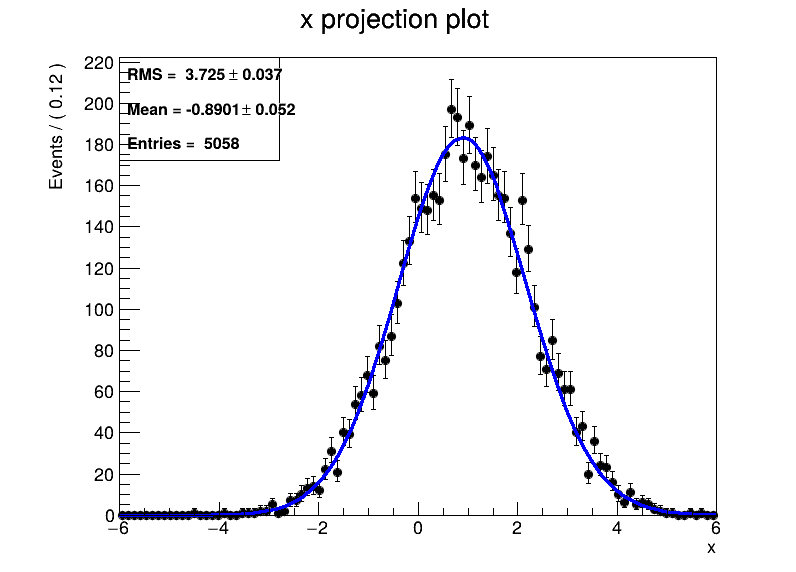

Info in <TCanvas::Print>: png file plot.png has been created


In [9]:
%jsroot on
p.set_statOn()
p.make_plot(pdf_format=False)
from IPython.display import Image
Image(filename='plot.png') 

Uniform


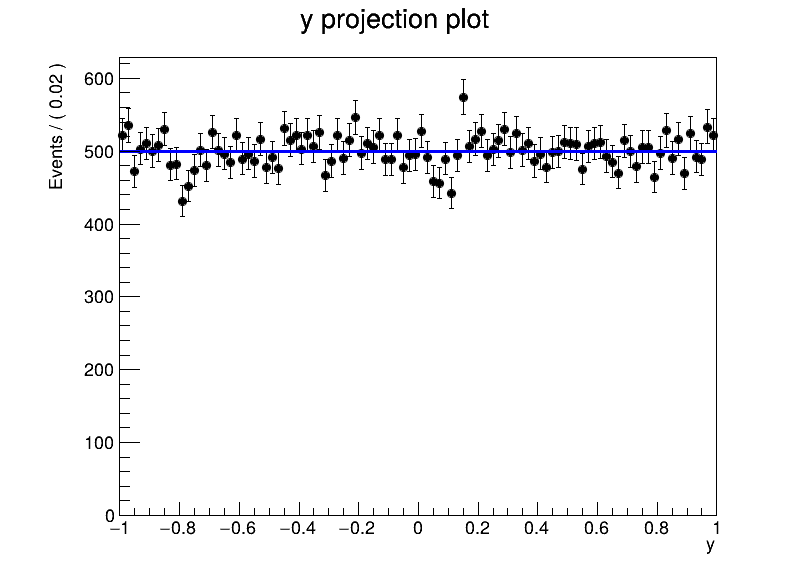

[#1] INFO:Plotting -- RooAbsReal::plotOn(Gauss_xy * Uniform_y) plot on y integrates over variables (x)


Info in <TCanvas::Print>: png file plot.png has been created


In [10]:
p = rff.RooFitPlot(dataset,f_xy,"y","y projection plot")
p.make_plot(pdf_format=False)
from IPython.display import Image
Image(filename='plot.png')

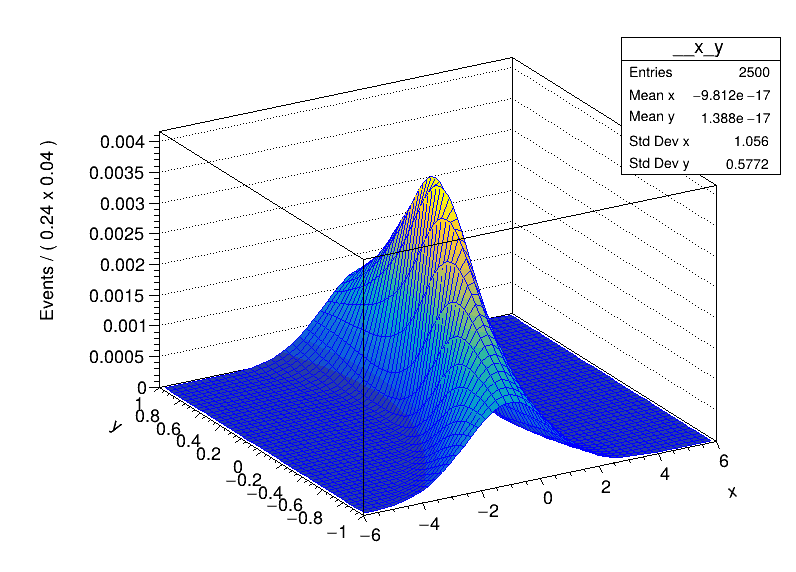

Info in <TCanvas::Print>: png file 2dplot.png has been created


In [11]:
p.make_2d_plot(pdf_format=False)
from IPython.display import Image
Image(filename='2dplot.png') 

Теперь разобьем область определения переменной y на бины. В каждом бине фитируем данные гауссовой плотностью и нарисуем зависимость $\mu(y)$ и $\sigma(y)$. После этого, сделаем оптимизацию гиперпараметра, используя введенную ранее эвристику.

In [12]:
bins = 10
data = dataset.dataset.to_numpy()
x_data = data['x']
y_data = data['y']
data = np.c_[x_data,y_data]
n,xe = np.histogram(y_data,bins=bins)
means = (xe[1:] + xe[:-1])/2
delta = (xe[1:] - xe[:-1])/2
means,xe,delta

(array([-0.89995086, -0.69995622, -0.49996158, -0.29996694, -0.0999723 ,
         0.10002234,  0.30001699,  0.50001163,  0.70000627,  0.90000091]),
 array([-9.99948183e-01, -7.99953542e-01, -5.99958900e-01, -3.99964259e-01,
        -1.99969617e-01,  2.50241719e-05,  2.00019666e-01,  4.00014307e-01,
         6.00008949e-01,  8.00003590e-01,  9.99998231e-01]),
 array([0.09999732, 0.09999732, 0.09999732, 0.09999732, 0.09999732,
        0.09999732, 0.09999732, 0.09999732, 0.09999732, 0.09999732]))

In [13]:
fit_results, fit_results_hyper = [], []
fit_qualities, fit_qualities_hyper = [], []
x_pdfs, x_pdfs_hyper = [], []
for i in np.arange(bins):
    condition = (data[:,1] > xe[i]) & (data[:,1] < xe[i+1])
    de_pdf = rff.RooFitFunction(f"Gauss_y_bins_{i}-0",{'all' : gauss_xy},"Gaussian",{f"mean{i}-0":[0,-2,2],f"sigma{i}-0":[0.5,0,1.5]})
    binned_data = rff.RooFitData("binned_data","binned",data[condition][:,0].reshape(-1,1),de_pdf.x,bins=50)
    r = rff.RooFitMaker(binned_data,de_pdf,"ML")
    fit_results.append(r.give_fit_results())
    fit_qualities.append(r.give_fit_quality())
    x_pdfs.append(de_pdf)
for i in np.arange(bins-1):
    condition = (data[:,1] > means[i]) & (data[:,1] < means[i+1])
    de_pdf = rff.RooFitFunction(f"Gauss_y_bins_{i}-1",{'all' : gauss_xy},"Gaussian",{f"mean{i}-1":[0,-2,2],f"sigma{i}-1":[0.5,0,1.5]})
    binned_data = rff.RooFitData("binned_data","binned",data[condition][:,0].reshape(-1,1),de_pdf.x,bins=50)
    r = rff.RooFitMaker(binned_data,de_pdf,"ML")
    fit_results_hyper.append(r.give_fit_results())
    fit_qualities_hyper.append(r.give_fit_quality())
    x_pdfs_hyper.append(de_pdf)

[#0] WARNING:InputArguments -- The parameter 'sigma0-0' with range [0, 1.5] of the RooGaussian 'Gauss_y_bins_0-0' exceeds the safe range of (0, inf). Advise to limit its range.
[#1] INFO:Fitting -- RooAbsPdf::fitTo(Gauss_y_bins_0-0_over_Gauss_y_bins_0-0_Int[x]) fixing normalization set for coefficient determination to observables in data
[#1] INFO:Fitting -- using generic CPU library compiled with no vectorizations
[#1] INFO:Fitting -- Creation of NLL object took 1.69071 ms
[#1] INFO:Fitting -- RooAbsPdf::fitTo(Gauss_y_bins_0-0_over_Gauss_y_bins_0-0_Int[x]) fixing normalization set for coefficient determination to observables in data
[#1] INFO:Fitting -- Creation of NLL object took 155.728 μs
[#1] INFO:Fitting -- RooAddition::defaultErrorLevel(nll_Gauss_y_bins_0-0_over_Gauss_y_bins_0-0_Int[x]_) Summation contains a RooNLLVar, using its error level
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::

In [14]:
fit_qualities

[{'Status': 0, 'Quality': 3, 'EDM': 0.0002597259201802278},
 {'Status': 0, 'Quality': 3, 'EDM': 0.00042810517836321235},
 {'Status': 0, 'Quality': 3, 'EDM': 0.00048339816221973294},
 {'Status': 0, 'Quality': 3, 'EDM': 2.0362233149630731e-07},
 {'Status': 0, 'Quality': 3, 'EDM': 6.569871455132305e-07},
 {'Status': 0, 'Quality': 3, 'EDM': 5.576307468887455e-06},
 {'Status': 0, 'Quality': 3, 'EDM': 4.8516550758157336e-05},
 {'Status': 0, 'Quality': 3, 'EDM': 0.00029927645726828304},
 {'Status': 0, 'Quality': 3, 'EDM': 0.00039727483632832455},
 {'Status': 0, 'Quality': 3, 'EDM': 1.975631633087488e-06}]

In [15]:
mu_values =    np.array([d[k][0] for d in fit_results for k in d.keys() if set('mean') < set(k)])
sigma_values = np.array([d[k][0] for d in fit_results for k in d.keys() if set('sigma') < set(k)])
mu_err_values = np.array([d[k][1] for d in fit_results for k in d.keys() if set('mean') < set(k)])
sigma_err_values = np.array([d[k][1] for d in fit_results for k in d.keys() if set('sigma') < set(k)])

In [16]:
mu_2_values =    np.array([d[k][0] for d in fit_results_hyper for k in d.keys() if set('mean') < set(k)])
sigma_2_values = np.array([d[k][0] for d in fit_results_hyper for k in d.keys() if set('sigma') < set(k)])
mu_err_2_values = np.array([d[k][1] for d in fit_results_hyper for k in d.keys() if set('mean') < set(k)])
sigma_err_2_values = np.array([d[k][1] for d in fit_results_hyper for k in d.keys() if set('sigma') < set(k)])

In [17]:
sigma_values, sigma_err_values

(array([1.31103625, 1.00251225, 0.76552468, 0.59395673, 0.51753311,
        0.52151732, 0.60439033, 0.75019972, 0.99514979, 1.33853936]),
 array([0.01308813, 0.01016228, 0.00765615, 0.00589316, 0.00517692,
        0.00524005, 0.00599267, 0.00750895, 0.0100262 , 0.0133687 ]))

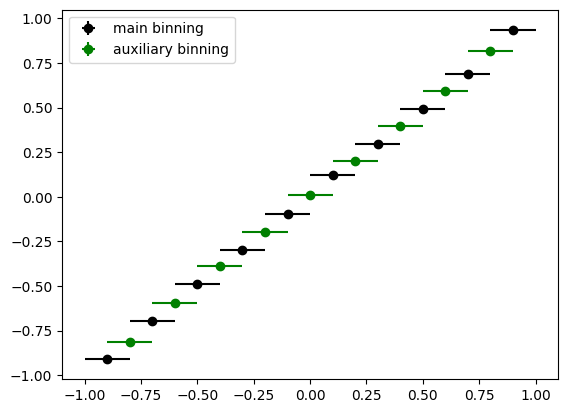

In [18]:
plt.errorbar(means,mu_values,xerr=delta,yerr=mu_err_values,fmt='ok',label='main binning')
plt.errorbar(xe[1:-1],mu_2_values,xerr=delta[1:],yerr=mu_err_2_values,fmt='og',label='auxiliary binning')
plt.legend(loc='upper left')

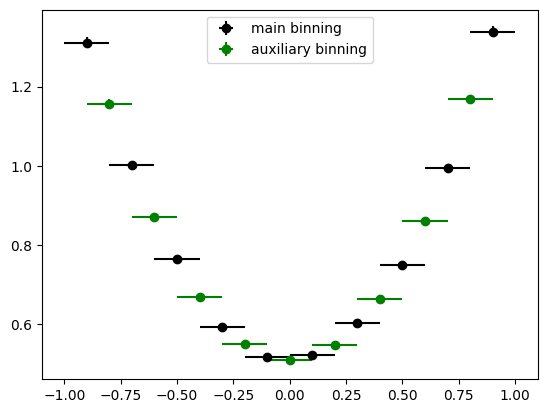

In [19]:
plt.errorbar(means,sigma_values,xerr=delta,yerr=sigma_err_values,fmt='ok',label='main binning')
plt.errorbar(xe[1:-1],sigma_2_values,xerr=delta[1:],yerr=sigma_err_2_values,fmt='og',label='auxiliary binning')
plt.legend(loc='upper center')

In [20]:
xe

array([-9.99948183e-01, -7.99953542e-01, -5.99958900e-01, -3.99964259e-01,
       -1.99969617e-01,  2.50241719e-05,  2.00019666e-01,  4.00014307e-01,
        6.00008949e-01,  8.00003590e-01,  9.99998231e-01])

In [21]:
# Оптимизация модели сигмоида 
def get_f(xe,means,k,opt):
    res_step = rff.RooFitVar({'y' : mu}, '0', {},'0')
    
    if opt == 1:
        xe_mod = xe.copy()
#        xe_mod[0] -= delta[0] / k
#        xe_mod[-1] += delta[-1] / k
        for i in range(len(xe)-1):
            smoothed_step = rff.RooFitVar({'y' : mu}, f'(1./(1+exp(-k{i}*(y-a{i})))-1./(1+exp(-k{i}*(y-b{i}))))/(1./(1+exp(-k{i}*(y-a_tot{i})))-1./(1+exp(-k{i}*(y-b_tot{i}))))', {f'k{i}' : k, f'a{i}' : xe_mod[i], f'b{i}' : xe_mod[i+1], f'a_tot{i}' : xe_mod[0], f'b_tot{i}' : xe_mod[-1]}, f'Sigma_{i}')
            res_step = res_step + x_pdfs[i]*smoothed_step
            del smoothed_step
        return rff.wrapped(res_step,selfNormalized=True,x_conditional=mu.x)*uniform_y
        
    elif opt == 2:
        res_step = rff.RooFitVar({"y": mu}, 'step', {'weights' : [p.function for p in x_pdfs_hyper], 'BinBounds' : list(means)}, 'step')
        return rff.wrapped(res_step,selfNormalized=True,x_conditional=mu.x)*uniform_y


In [22]:
get_f(xe,means,1,2).x_limits

{'y': [-1, 1]}

In [23]:
[x.GetName() for x in get_f(xe,means,1,2).x]

['y']

In [24]:
get_f(xe,means,1,1).x_limits

{'x': [-6, 6], 'y': [-1, 1]}

In [25]:
loss_max = 1e6
loss_ = []
k_opt = None
for k in np.arange(1,100,10):
    k = int(k)
    condition = (data[:,1] > means[0]) & (data[:,1] < means[bins-1])
    data_inner = data[condition]
    loss = np.mean(np.abs(rff.digit_function(get_f(xe,means,k,1),dataset,{'y' : [means[0],means[bins-1]]})[-1] - 
                          rff.digit_function(get_f(xe,means,k,2),dataset,{'y' : [means[0],means[bins-1]]})[-1]))
    loss_.append(loss)
    if loss < loss_max:
        loss_max  = loss
        k_opt = k
loss_max,k_opt

(np.float64(0.1513161513278245), 91)

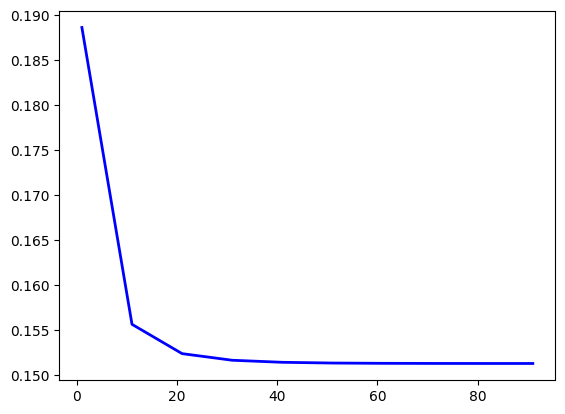

In [26]:
plt.plot(np.arange(1,100,10),loss_,color='blue',linewidth=2)

In [28]:
estimated_function = get_f(xe,means,20,1)
[x.GetName() for x in estimated_function.x]

['x', 'y']

In [29]:
p = rff.RooFitPlot(dataset,estimated_function,"y","y projection plot")

Uniform
[#1] INFO:Plotting -- RooAbsReal::plotOn(PDF_0(+)Sigma_0(*)Gauss_y_bins_0-0(+)Sigma_1(*)Gauss_y_bins_1-0(+)Sigma_2(*)Gauss_y_bins_2-0(+)Sigma_3(*)Gauss_y_bins_3-0(+)Sigma_4(*)Gauss_y_bins_4-0(+)Sigma_5(*)Gauss_y_bins_5-0(+)Sigma_6(*)Gauss_y_bins_6-0(+)Sigma_7(*)Gauss_y_bins_7-0(+)Sigma_8(*)Gauss_y_bins_8-0(+)Sigma_9(*)Gauss_y_bins_9-0 * Uniform_y) plot on y integrates over variables (x)


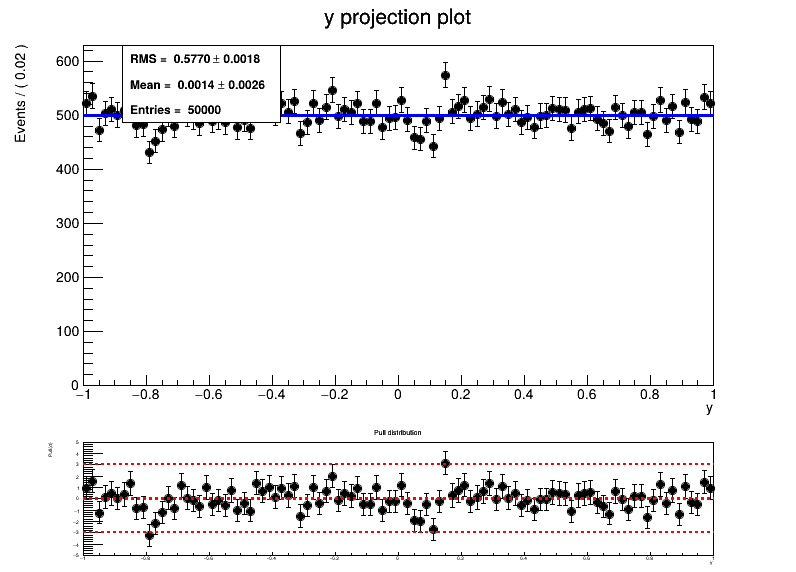

Info in <TCanvas::Print>: png file pull.png has been created


In [30]:
%jsroot on
p.set_statOn()
p.make_pullplot(pdf_format=False)
from IPython.display import Image
Image(filename='pull.png') 

In [31]:
xe

array([-9.99948183e-01, -7.99953542e-01, -5.99958900e-01, -3.99964259e-01,
       -1.99969617e-01,  2.50241719e-05,  2.00019666e-01,  4.00014307e-01,
        6.00008949e-01,  8.00003590e-01,  9.99998231e-01])

In [32]:
p = rff.RooFitPlot(dataset,estimated_function,"x","x projection plot")

[#1] INFO:Plotting -- RooAbsReal::plotOn(PDF_0(+)Sigma_0(*)Gauss_y_bins_0-0(+)Sigma_1(*)Gauss_y_bins_1-0(+)Sigma_2(*)Gauss_y_bins_2-0(+)Sigma_3(*)Gauss_y_bins_3-0(+)Sigma_4(*)Gauss_y_bins_4-0(+)Sigma_5(*)Gauss_y_bins_5-0(+)Sigma_6(*)Gauss_y_bins_6-0(+)Sigma_7(*)Gauss_y_bins_7-0(+)Sigma_8(*)Gauss_y_bins_8-0(+)Sigma_9(*)Gauss_y_bins_9-0 * Uniform_y) plot on x integrates over variables (y)
[#1] INFO:NumericIntegration -- RooRealIntegral::init([Uniform_y_NORM[y]_X_PDF_0(+)Sigma_0(*)Gauss_y_bins_0-0(+)Sigma_1(*)Gauss_y_bins_1-0(+)Sigma_2(*)Gauss_y_bins_2-0(+)Sigma_3(*)Gauss_y_bins_3-0(+)Sigma_4(*)Gauss_y_bins_4-0(+)Sigma_5(*)Gauss_y_bins_5-0(+)Sigma_6(*)Gauss_y_bins_6-0(+)Sigma_7(*)Gauss_y_bins_7-0(+)Sigma_8(*)Gauss_y_bins_8-0(+)Sigma_9(*)Gauss_y_bins_9-0_NORM[x]]_Int[y]) using numeric integrator RooIntegrator1D to calculate Int(y)


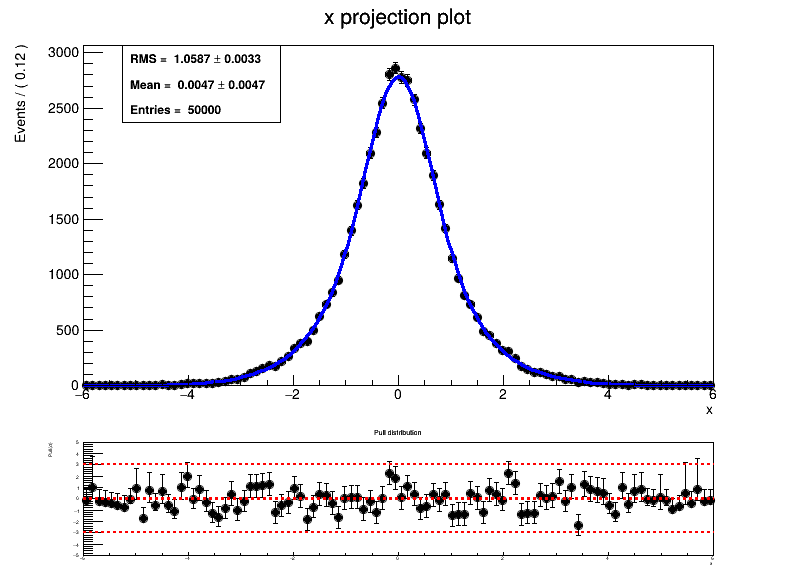

Info in <TCanvas::Print>: png file pull.png has been created


In [33]:
%jsroot on
p.set_statOn()
p.make_pullplot(pdf_format=False)
from IPython.display import Image
Image(filename='pull.png') 

Gaussian|(y)


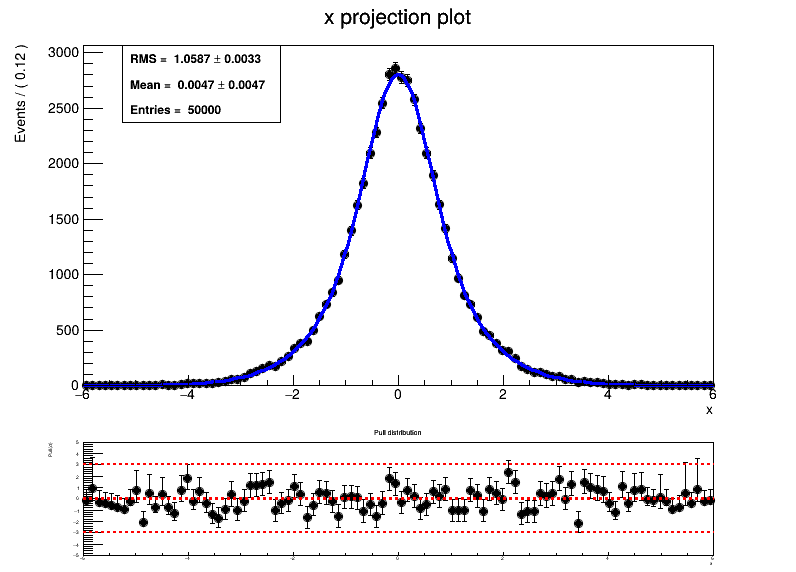

[#1] INFO:Plotting -- RooAbsReal::plotOn(Gauss_xy * Uniform_y) plot on x integrates over variables (y)
[#1] INFO:NumericIntegration -- RooRealIntegral::init([Uniform_y_NORM[y]_X_Gauss_xy_NORM[x]]_Int[y]) using numeric integrator RooIntegrator1D to calculate Int(y)


Info in <TCanvas::Print>: png file pull.png has been created


In [34]:
%jsroot on
p1 = rff.RooFitPlot(dataset,f_xy,"x","x projection plot")
p1.set_statOn()
p1.make_pullplot(pdf_format=False)
from IPython.display import Image
Image(filename='pull.png') 